# Day 2: Breaking Linearity
## The Multi-Layer Perceptron (MLP) & The XOR Problem
---
**Objective:** Understand why linear models fail at complex tasks and how introducing "hidden layers" with non-linear activation functions allows neural networks to solve them.

### The Plan:
1. **The XOR Problem**: Introduce a dataset that is not linearly separable.
2. **The Linear Failure**: Prove practically that a stacked linear network cannot solve it.
3. **Activation Functions**: Introduce ReLU and Sigmoid as the mathematical "bends".
4. **Building the MLP**: Construct a 2-layer network using `nn.Module`.
5. **Visualization**: See the decision boundary bend around the data points.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# Ensure reproducibility
torch.manual_seed(42)

### 2.1 The Indestructible XOR Problem
Day 1's model drew straight lines. Exclusive OR (XOR) is the simplest problem where a straight line cannot separate the classes.

Inputs (x1, x2) | Output (y)
---|---
0, 0 | 0
0, 1 | 1
1, 0 | 1
1, 1 | 0

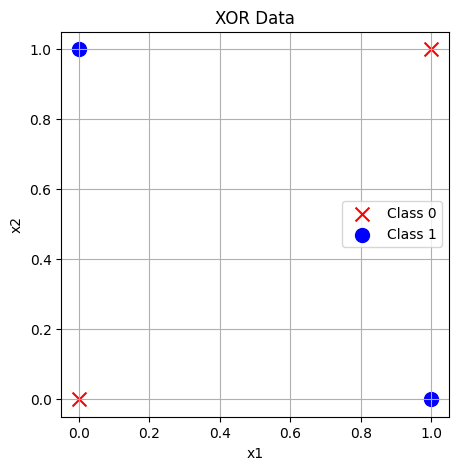

In [2]:
# Data Setup
X_xor = torch.tensor([[0,0], [0,1], [1,0], [1,1]], dtype=torch.float32)
y_xor = torch.tensor([[0], [1], [1], [0]], dtype=torch.float32)

# Visualization Function
def plot_data(X, y, title="XOR Data"):
    plt.figure(figsize=(5,5))
    plt.scatter(X[y[:,0]==0, 0], X[y[:,0]==0, 1], c='red', marker='x', s=100, label='Class 0')
    plt.scatter(X[y[:,0]==1, 0], X[y[:,0]==1, 1], c='blue', marker='o', s=100, label='Class 1')
    plt.grid(True)
    plt.legend()
    plt.title(title)
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.show()

plot_data(X_xor, y_xor)
# Try mentally drawing a single straight line that separates red crosses from blue dots. You can't.

### 2.2 Why stacking linear layers doesn't work

You might think: "If one linear layer isn't enough, let's use two!"

Mathematically, if layer 1 is $Z_1 = W_1X + b_1$ and layer 2 is $Z_2 = W_2Z_1 + b_2$, substituting them gives:

$$ Z_2 = W_2(W_1X + b_1) + b_2 $$
$$ Z_2 = (W_2W_1)X + (W_2b_1 + b_2) $$

This is still just a new linear equation $Y = W_{new}X + b_{new}$. Stacking linear layers without non-linearity is pointless. Let's prove it with code.

In [3]:
# A "Deep" Linear Network (will fail)
model_linear = nn.Sequential(
    nn.Linear(2, 8), # Hidden layer with 8 neurons
    # NO ACTIVATION FUNCTION HERE
    nn.Linear(8, 1), # Output layer
    nn.Sigmoid()     # Just to squash output between 0-1 for probability
)

# Training setup (Binary Cross Entropy is used for yes/no classification)
criterion = nn.BCELoss() 
optimizer = optim.SGD(model_linear.parameters(), lr=0.1)

# Quick train loop
print("Training Linear Stack...")
for epoch in range(1001):
    optimizer.zero_grad()
    output = model_linear(X_xor)
    loss = criterion(output, y_xor)
    loss.backward()
    optimizer.step()
    if epoch % 200 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")
        
print("\nFinal Predictions (Linear Stack):")
print(model_linear(X_xor).detach().round())
# It will likely predict all zeros or all ones, or 0.5 for everything. It fails.

Training Linear Stack...
Epoch 0, Loss: 0.7167
Epoch 200, Loss: 0.6933
Epoch 400, Loss: 0.6932
Epoch 600, Loss: 0.6931
Epoch 800, Loss: 0.6931
Epoch 1000, Loss: 0.6931

Final Predictions (Linear Stack):
tensor([[1.],
        [0.],
        [1.],
        [0.]])


### 2.3 The Fix: Activation Functions
We need to inject non-linearity between the layers. This allows the network to *bend* the decision boundary.

We will use **ReLU (Rectified Linear Unit)** in the hidden layer. It's deceptively simple: if x > 0, keep x. If x <= 0, become 0.
$$ f(x) = max(0, x) $$

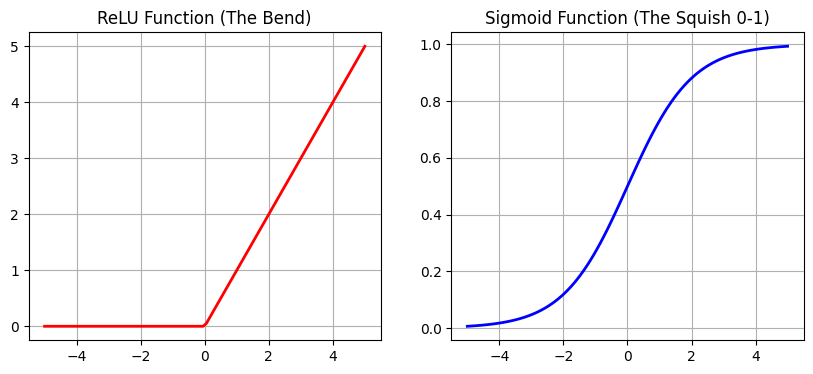

In [4]:
x_range = torch.linspace(-5, 5, 100)
relu_out = torch.relu(x_range)
sigmoid_out = torch.sigmoid(x_range)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(x_range, relu_out, 'r', linewidth=2)
plt.title("ReLU Function (The Bend)")
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(x_range, sigmoid_out, 'b', linewidth=2)
plt.title("Sigmoid Function (The Squish 0-1)")
plt.grid(True)
plt.show()

### 2.4 Building the Multi-Layer Perceptron (MLP)
We will create a professional PyTorch class. 
Architecture: Input(2) -> Hidden(4 neurons) -> ReLU -> Output(1 neuron) -> Sigmoid.

In [5]:
class XORMLP(nn.Module):
    def __init__(self):
        super().__init__()
        # Hidden Layer: Takes 2 inputs, outputs to 4 "hidden" features
        self.layer1 = nn.Linear(2, 4) 
        # The non-linearity
        self.relu = nn.ReLU()
        # Output Layer: Takes the 4 hidden features, outputs 1 prediction
        self.layer2 = nn.Linear(4, 1)
        # Final activation for probability between 0 and 1
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        # Pass input through layer 1
        x = self.layer1(x)
        # Apply the "bend"
        x = self.relu(x)
        # Pass through layer 2
        x = self.layer2(x)
        # Squash to probability
        x = self.sigmoid(x)
        return x

model_mlp = XORMLP()
print(model_mlp)

XORMLP(
  (layer1): Linear(in_features=2, out_features=4, bias=True)
  (relu): ReLU()
  (layer2): Linear(in_features=4, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


### 2.5 Training the MLP
We use the same training loop structure as Day 1, but with binary classification loss.

Training MLP...
Epoch 0, Loss: 0.6941, Accuracy: 0.75
Epoch 200, Loss: 0.6931, Accuracy: 0.50
Epoch 400, Loss: 0.6931, Accuracy: 0.50
Epoch 600, Loss: 0.6931, Accuracy: 0.50
Epoch 800, Loss: 0.6931, Accuracy: 0.50
Epoch 1000, Loss: 0.6931, Accuracy: 0.50


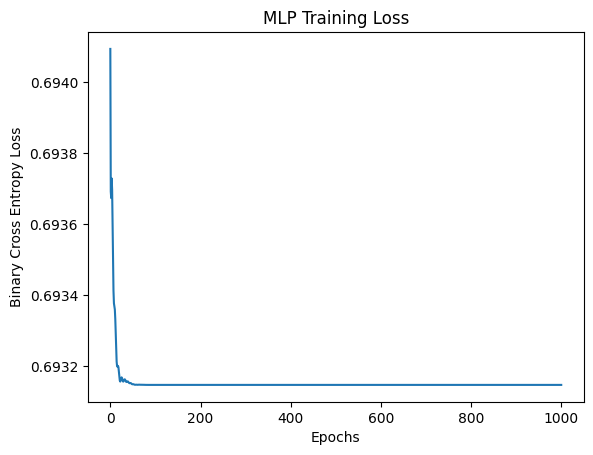

In [6]:
# Re-initialize optimizer for the new model
# Using Adam optimizer this time, it's generally faster than SGD for this
optimizer = optim.Adam(model_mlp.parameters(), lr=0.01)
criterion = nn.BCELoss()

losses = []

print("Training MLP...")
for epoch in range(1001):
    # Standard PyTorch Loop
    optimizer.zero_grad()
    outputs = model_mlp(X_xor)
    loss = criterion(outputs, y_xor)
    loss.backward()
    optimizer.step()
    
    losses.append(loss.item())
    
    if epoch % 200 == 0:
        # Calculate accuracy
        preds = outputs.round()
        acc = (preds == y_xor).float().mean()
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}, Accuracy: {acc.item():.2f}")

plt.plot(losses)
plt.title("MLP Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Binary Cross Entropy Loss")
plt.show()

### 2.6 Visualizing the "Bent" Decision Boundary
This is the most important part. We will evaluate the model on a grid of thousands of points to see exactly where it draws the line between Class 0 and Class 1.

C:\Users\RJ\AppData\Local\Temp\ipykernel_1640\2030574945.py:8: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))


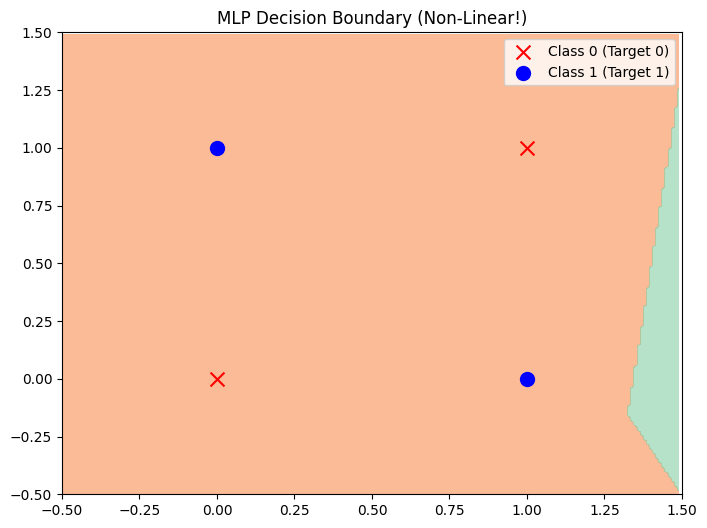

In [12]:
def plot_decision_boundary(model, X, y):
    # Set grid boundaries to cover XOR points and a bit more for clarity
    x_min, x_max = X[:,0].min() - 0.5, X[:,0].max() + 0.5
    y_min, y_max = X[:,1].min() - 0.5, X[:,1].max() + 0.5
    h = 0.01 # Grid step size
    
    # Generate the grid
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    
    # Prepare grid points for prediction
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    grid_tensor = torch.tensor(grid_points, dtype=torch.float32)
    
    with torch.no_grad():
        Z = model(grid_tensor)
        Z = Z.numpy().reshape(xx.shape)
        Z = (Z > 0.5).astype(int)  # Threshold at 0.5 for binary classification
    
    # Plotting
    plt.figure(figsize=(8,6))
    plt.contourf(xx, yy, Z, levels=[-0.5,0.5,1.5], cmap=plt.cm.Spectral, alpha=0.6)
    plt.scatter(X[y[:,0]==0, 0], X[y[:,0]==0, 1], c='red', marker='x', s=100, label='Class 0 (Target 0)')
    plt.scatter(X[y[:,0]==1, 0], X[y[:,0]==1, 1], c='blue', marker='o', s=100, label='Class 1 (Target 1)')
    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)
    plt.title("MLP Decision Boundary (Non-Linear!)")
    plt.legend()
    plt.show()

plot_decision_boundary(model_mlp, X_xor, y_xor)

### Day 2 Lab Challenges:
1.  **Change the Activation**: Replace `self.relu = nn.ReLU()` with `self.tanh = nn.Tanh()` in the `XORMLP` class. Retrain and plot the boundary. Does Tanh bend the space differently than ReLU?
2.  **Add More Power**: Increase the hidden neurons from 4 to 20 (`nn.Linear(2, 20)` and `nn.Linear(20, 1)`). Does the model converge faster? Is the decision boundary smoother or sharper?
3.  **Break it again**: Remove the `self.relu(x)` line from the `forward` method of your MLP class, but keep the layers. Retrain. Does it fail again, confirming the linear stacking theory?